# *Lepidonotopodium piscesae* — Detection Analysis
**Site:** Mushroom Vent, Axial Seamount | **System:** CAMHD OOI | **Period:** Oct 2024

Parses YOLO-format `.txt` label files from the verified export directory to produce:
- Scale worms detected over time (daily + cumulative)
- Detections per frame distribution
- Bounding box size distribution (detection geometry proxy)
- Day × Hour activity heatmap
- Summary metrics table

## 1. Imports

In [1]:
import os
import re
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

TEAL   = '#2ec4b6'
ORANGE = '#e76f51'
BLUE   = '#457b9d'
GOLD   = '#e9c46a'

print('Imports ready.')

Imports ready.


## 2. Configuration

In [2]:
# ── Edit this path if your export folder moves ──────────────────────────────
EXPORT_DIR = Path('/home/jovyan/scaleworm-student-lab/notebooks/verification_session/export')

IMAGES_DIR = EXPORT_DIR / 'images' / 'train'
LABELS_DIR = EXPORT_DIR / 'labels' / 'train'
YAML_PATH  = EXPORT_DIR / 'dataset.yaml'

# Filename pattern: CAMHDA301-20241001T061500_frame_0011.png
# Group 1 = YYYYMMDD, Group 2 = HHMMSS, Group 3 = frame index
FNAME_REGEX = re.compile(r'(\d{8})T(\d{6})_frame_(\d+)')

print(f'Export dir : {EXPORT_DIR}')
print(f'Exists     : {EXPORT_DIR.exists()}')
print(f'images/    : {IMAGES_DIR.exists()}')
print(f'labels/    : {LABELS_DIR.exists()}')
print(f'yaml       : {YAML_PATH.exists()}')

Export dir : /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export
Exists     : True
images/    : True
labels/    : True
yaml       : True


## 3. Load dataset.yaml

In [3]:
if YAML_PATH.exists():
    with open(YAML_PATH, 'r') as f:
        meta = yaml.safe_load(f)
    print('dataset.yaml contents:')
    for k, v in meta.items():
        print(f'  {k}: {v}')
else:
    print('dataset.yaml not found — using known values as fallback.')
    meta = {}

# Fall back to your known values if keys differ in your yaml
YAML_TOTAL_DETECTIONS = meta.get('total_detections', 3611)
YAML_SOURCE_FRAMES    = meta.get('source_frames',    1152)
YAML_DATE_START       = meta.get('date_start', '2024-10-01')
YAML_DATE_END         = meta.get('date_end',   '2024-10-31')

dataset.yaml contents:
  path: .
  train: images/train
  val: images/train
  nc: 1
  names: {0: 'scale_worm'}


## 4. Parse Label Files

In [4]:
def parse_timestamp(stem):
    """Extract datetime and frame index from filename stem.
    Handles: CAMHDA301-20241001T061500_frame_0011
    """
    m = FNAME_REGEX.search(stem)
    if not m:
        return None, None
    try:
        dt = datetime.strptime(f'{m.group(1)}{m.group(2)}', '%Y%m%d%H%M%S')
    except ValueError:
        return None, None
    return dt, int(m.group(3))


records = []
parse_failures = 0

# Collect all txt files; also accept stems matched from images/
if LABELS_DIR.exists():
    txt_files = sorted(LABELS_DIR.glob('*.txt'))
else:
    img_exts = {'.png', '.jpg', '.jpeg'}
    txt_files = []
    for img in sorted(IMAGES_DIR.glob('*')):
        if img.suffix.lower() in img_exts:
            lbl = LABELS_DIR / (img.stem + '.txt')
            if lbl.exists():
                txt_files.append(lbl)

print(f'Label files found: {len(txt_files)}')

for txt in txt_files:
    dt, frame_idx = parse_timestamp(txt.stem)
    if dt is None:
        parse_failures += 1
        continue

    with open(txt, 'r') as f:
        lines = [l.strip() for l in f if l.strip()]

    if lines:
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            records.append({
                'filename':  txt.stem,
                'timestamp': dt,
                'date':      dt.date(),
                'hour':      dt.hour,
                'frame_idx': frame_idx,
                'class_id':  int(parts[0]),
                'x_center':  float(parts[1]),
                'y_center':  float(parts[2]),
                'bbox_w':    float(parts[3]),
                'bbox_h':    float(parts[4]),
                'bbox_area': float(parts[3]) * float(parts[4]),
            })
    else:
        # Frame present but no detections
        records.append({
            'filename': txt.stem, 'timestamp': dt,
            'date': dt.date(), 'hour': dt.hour,
            'frame_idx': frame_idx,
            'class_id': None, 'x_center': None, 'y_center': None,
            'bbox_w': None, 'bbox_h': None, 'bbox_area': None,
        })

df      = pd.DataFrame(records)
df_dets = df[df['class_id'].notna()].copy()

print(f'Frames parsed        : {df["filename"].nunique()}')
print(f'Total detections     : {len(df_dets)}')
print(f'Frames with no dets  : {df["class_id"].isna().sum()}')
print(f'Parse failures       : {parse_failures}')
df_dets.head()

Label files found: 1213
Frames parsed        : 1213
Total detections     : 2438
Frames with no dets  : 0
Parse failures       : 0


,filename,timestamp,date,hour,frame_idx,class_id,x_center,y_center,bbox_w,bbox_h,bbox_area
0,CAMHDA301-20241001T061500_frame_0011,2024-10-01 06:15:00,2024-10-01,6,11,0,0.612676,0.612738,0.037739,0.021091,0.000796
1,CAMHDA301-20241001T091500_frame_0001,2024-10-01 09:15:00,2024-10-01,9,1,0,0.801935,0.875892,0.064145,0.091671,0.005880
2,CAMHDA301-20241001T091500_frame_0001,2024-10-01 09:15:00,2024-10-01,9,1,0,0.678059,0.905213,0.023516,0.035731,0.000840
3,CAMHDA301-20241001T091500_frame_0002,2024-10-01 09:15:00,2024-10-01,9,2,0,0.808918,0.882858,0.060087,0.086161,0.005177
4,CAMHDA301-20241001T091500_frame_0002,2024-10-01 09:15:00,2024-10-01,9,2,0,0.678246,0.905377,0.023168,0.035216,0.000816


## 5. Aggregate

In [5]:
daily = (
    df_dets.groupby('date')
    .agg(
        detections      = ('class_id',  'count'),
        frames_with_det = ('filename',  'nunique'),
        mean_bbox_area  = ('bbox_area', 'mean'),
    )
    .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])
daily['cumulative_dets'] = daily['detections'].cumsum()

per_frame = (
    df_dets.groupby('filename')['class_id']
    .count()
    .reset_index()
    .rename(columns={'class_id': 'dets_per_frame'})
)

total_frames_parsed  = df['filename'].nunique()
frames_with_dets     = df_dets['filename'].nunique()
frames_no_dets       = total_frames_parsed - frames_with_dets
total_dets_parsed    = len(df_dets)
detection_rate       = frames_with_dets / total_frames_parsed if total_frames_parsed else 0
avg_dets_per_frame   = total_dets_parsed / frames_with_dets if frames_with_dets else 0
mean_bbox_area       = df_dets['bbox_area'].mean()
median_bbox_area     = df_dets['bbox_area'].median()

print('Daily aggregation complete.')

Daily aggregation complete.


## 6. Chart 1 — Scale Worms Detected Per Day

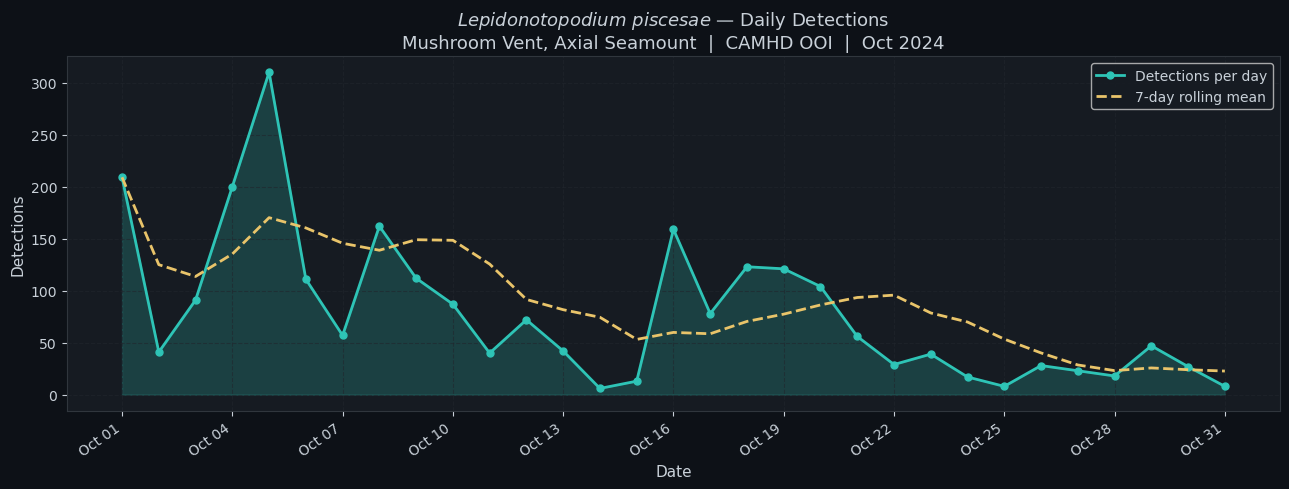

Saved: /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/fig1_daily_detections.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(daily['date'], daily['detections'], alpha=0.22, color=TEAL)
ax.plot(daily['date'], daily['detections'],
        color=TEAL, linewidth=2, marker='o', markersize=5,
        label='Detections per day')

if len(daily) >= 7:
    rolling = daily.set_index('date')['detections'].rolling('7D').mean()
    ax.plot(rolling.index, rolling.values,
            color=GOLD, linewidth=2, linestyle='--', label='7-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Detections')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Daily Detections'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend()
ax.grid(True)
fig.tight_layout()
out1 = EXPORT_DIR / 'fig1_daily_detections.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

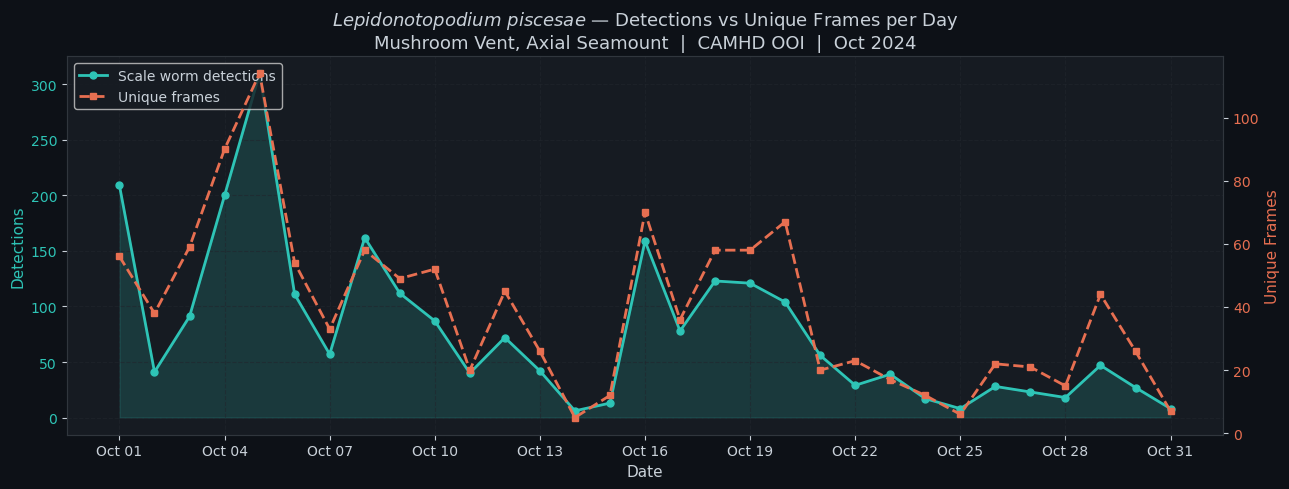

Saved: /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/fig_detections_vs_frames.png


In [7]:
# Frames per day (all parsed frames, not just those with detections)
frames_per_day = (
    df.groupby('date')['filename']
    .nunique()
    .reset_index()
    .rename(columns={'filename': 'unique_frames'})
)
frames_per_day['date'] = pd.to_datetime(frames_per_day['date'])

fig, ax1 = plt.subplots(figsize=(13, 5))

# Left axis — detections
ax1.fill_between(daily['date'], daily['detections'], alpha=0.18, color=TEAL)
ax1.plot(daily['date'], daily['detections'],
         color=TEAL, linewidth=2, marker='o', markersize=5,
         label='Scale worm detections')
ax1.set_xlabel('Date')
ax1.set_ylabel('Detections', color=TEAL)
ax1.tick_params(axis='y', labelcolor=TEAL)

# Right axis — frames
ax2 = ax1.twinx()
ax2.plot(frames_per_day['date'], frames_per_day['unique_frames'],
         color=ORANGE, linewidth=2, marker='s', markersize=5,
         linestyle='--', label='Unique frames')
ax2.set_ylabel('Unique Frames', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax1.set_title(
    r'$Lepidonotopodium\ piscesae$ — Detections vs Unique Frames per Day'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax1.grid(True)
fig.tight_layout()
out_skew = EXPORT_DIR / 'fig_detections_vs_frames.png'
plt.savefig(out_skew, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_skew}')

## 7. Chart 2 — Cumulative Detections

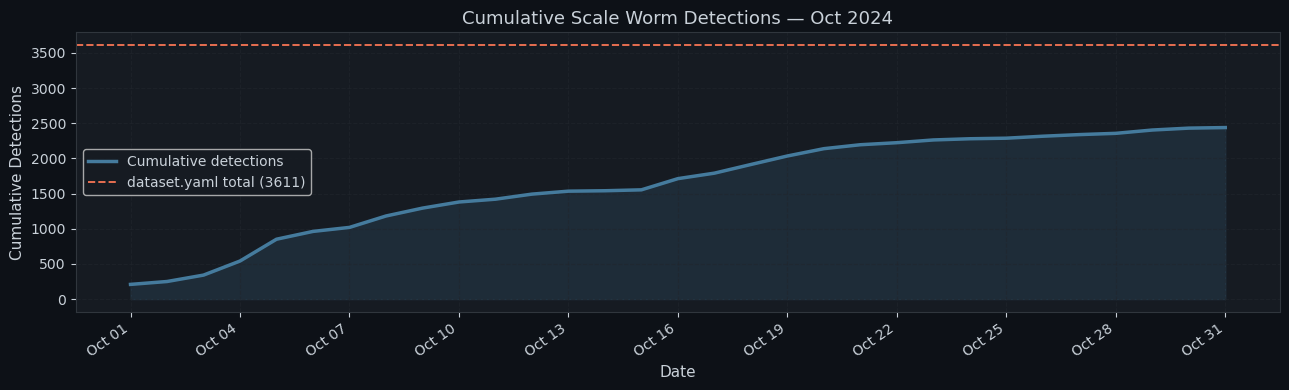

Saved: /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/fig2_cumulative.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(daily['date'], daily['cumulative_dets'], alpha=0.18, color=BLUE)
ax.plot(daily['date'], daily['cumulative_dets'],
        color=BLUE, linewidth=2.5, label='Cumulative detections')
ax.axhline(YAML_TOTAL_DETECTIONS, color=ORANGE, linewidth=1.4,
           linestyle='--', label=f'dataset.yaml total ({YAML_TOTAL_DETECTIONS})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Detections')
ax.set_title('Cumulative Scale Worm Detections — Oct 2024')
ax.legend()
ax.grid(True)
fig.tight_layout()
out2 = EXPORT_DIR / 'fig2_cumulative.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')

## 8. Chart 3 — Model Metrics (derived from .txt label files)

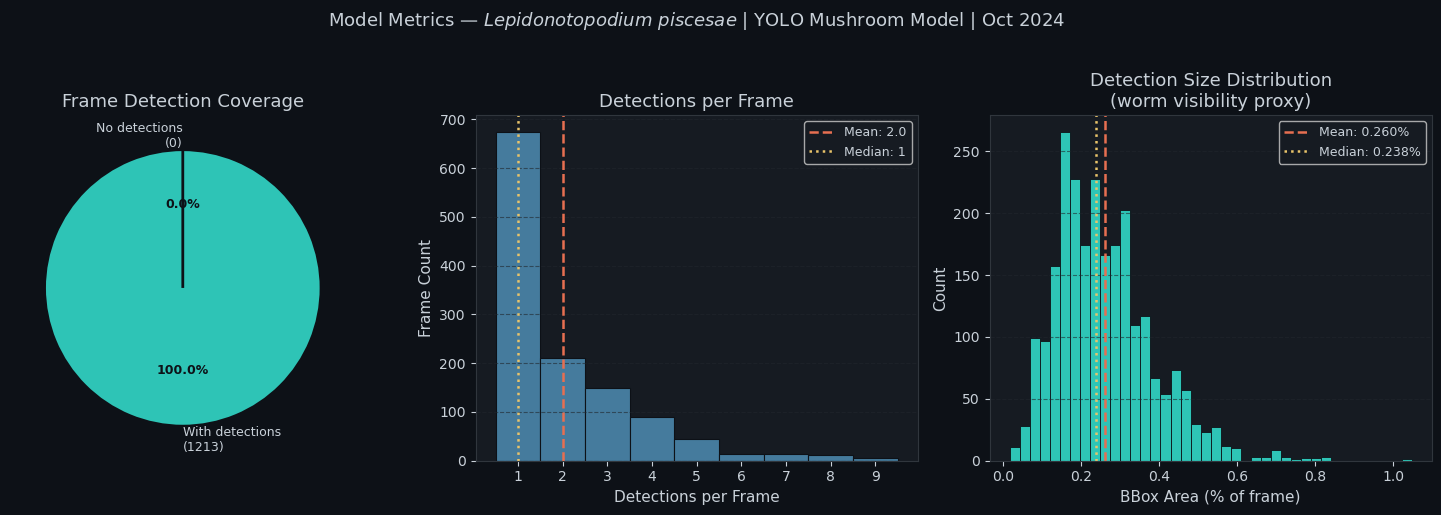

Saved: /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/fig3_model_metrics.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A — Frame coverage pie
ax = axes[0]
sizes  = [frames_with_dets, frames_no_dets]
labels = [
    f'With detections\n({frames_with_dets})',
    f'No detections\n({frames_no_dets})'
]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=[TEAL, '#30363d'],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': '#c9d1d9', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
ax.set_title('Frame Detection Coverage')

# Panel B — Detections per frame histogram
ax = axes[1]
counts = per_frame['dets_per_frame']
ax.hist(counts, bins=range(1, counts.max() + 2),
        color=BLUE, edgecolor='#0d1117', linewidth=0.8, align='left')
ax.axvline(counts.mean(),   color=ORANGE, linewidth=1.8,
           linestyle='--',  label=f'Mean: {counts.mean():.1f}')
ax.axvline(counts.median(), color=GOLD,   linewidth=1.8,
           linestyle=':',   label=f'Median: {counts.median():.0f}')
ax.set_xlabel('Detections per Frame')
ax.set_ylabel('Frame Count')
ax.set_title('Detections per Frame')
ax.legend(fontsize=9)
ax.grid(True, axis='y')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel C — Bounding box area distribution
ax = axes[2]
ax.hist(df_dets['bbox_area'] * 100, bins=40,
        color=TEAL, edgecolor='#0d1117', linewidth=0.6)
ax.axvline(mean_bbox_area   * 100, color=ORANGE, linewidth=1.8,
           linestyle='--', label=f'Mean: {mean_bbox_area*100:.3f}%')
ax.axvline(median_bbox_area * 100, color=GOLD,   linewidth=1.8,
           linestyle=':',  label=f'Median: {median_bbox_area*100:.3f}%')
ax.set_xlabel('BBox Area (% of frame)')
ax.set_ylabel('Count')
ax.set_title('Detection Size Distribution\n(worm visibility proxy)')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

fig.suptitle(
    r'Model Metrics — $Lepidonotopodium\ piscesae$ | YOLO Mushroom Model | Oct 2024',
    fontsize=13, y=1.02
)
fig.tight_layout()
out3 = EXPORT_DIR / 'fig3_model_metrics.png'
plt.savefig(out3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out3}')

## 9. Chart 4 — Day × Hour Activity Heatmap

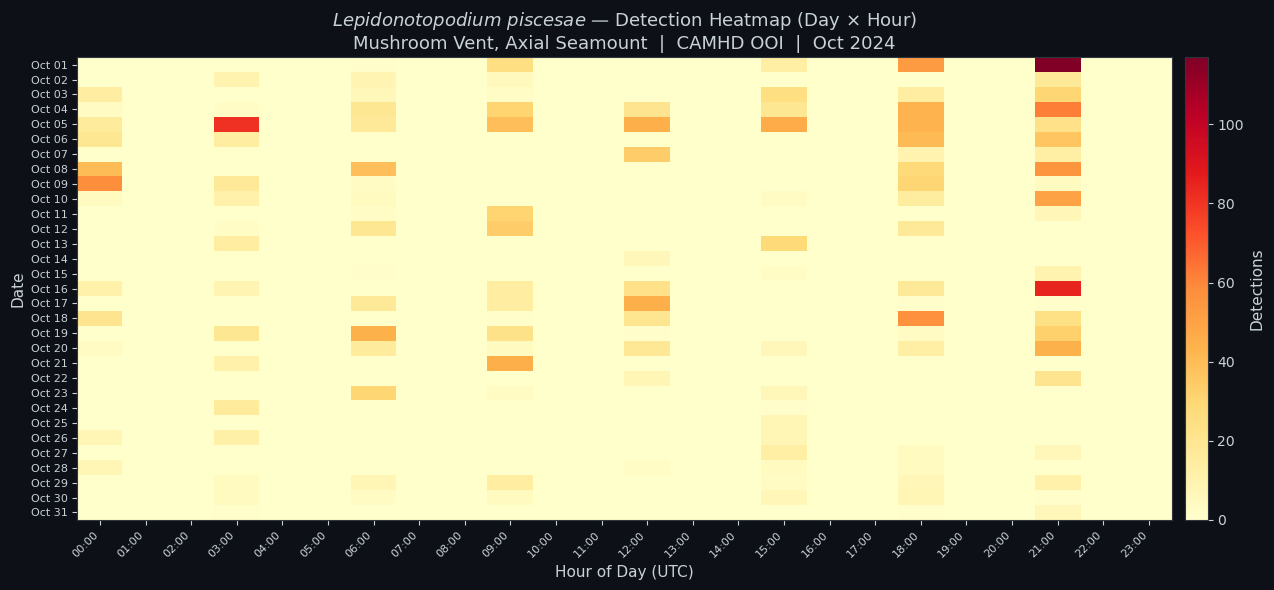

Saved: /home/jovyan/scaleworm-student-lab/notebooks/verification_session/export/fig4_heatmap.png


In [10]:
df_dets['day'] = pd.to_datetime(df_dets['date']).dt.day
heatmap_data = (
    df_dets.groupby(['day', 'hour'])['class_id']
    .count()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_data.values, aspect='auto',
               cmap='YlOrRd', interpolation='nearest')
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Detections', color='#c9d1d9')
cbar.ax.yaxis.set_tick_params(color='#c9d1d9')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#c9d1d9')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels([f'Oct {d:02d}' for d in heatmap_data.index], fontsize=8)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Date')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Detection Heatmap (Day × Hour)'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
fig.tight_layout()
out4 = EXPORT_DIR / 'fig4_heatmap.png'
plt.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out4}')

## 10. Summary Statistics

In [12]:
print('=' * 54)
print('  SUMMARY — YOLO Mushroom Model | Oct 2024')
print('=' * 54)
print(f'  Species        : Lepidonotopodium piscesae')
print(f'  Site           : Mushroom Vent, Axial Seamount')
print(f'  Date range     : {YAML_DATE_START}  →  {YAML_DATE_END}')
print('-' * 54)
print(f'  dataset.yaml reference totals')
print(f'    Verified detections : {YAML_TOTAL_DETECTIONS}')
print(f'    Source frames       : {YAML_SOURCE_FRAMES}')
print('-' * 54)
print(f'  Parsed from .txt label files')
print(f'    Frames parsed         : {total_frames_parsed}')
print(f'    Frames w/ detections  : {frames_with_dets}  ({detection_rate*100:.1f}%)')
print(f'    Frames w/o detections : {frames_no_dets}')
print(f'    Total detections      : {total_dets_parsed}')
print(f'    Avg dets / frame      : {avg_dets_per_frame:.2f}')
print(f'    Max dets in one frame : {per_frame["dets_per_frame"].max()}')
print('-' * 54)
print(f'  Bounding box geometry (normalised 0–1)')
print(f'    Mean bbox area   : {mean_bbox_area*100:.3f}% of frame')
print(f'    Median bbox area : {median_bbox_area*100:.3f}% of frame')
print(f'    Mean width       : {df_dets["bbox_w"].mean():.4f}')
print(f'    Mean height      : {df_dets["bbox_h"].mean():.4f}')
print('=' * 54)
print()
print('NOTE: YOLO .txt label files do not carry confidence scores.')
print('To add confidence metrics, re-run model inference with:')
print('  --save-txt --save-conf')
print('This appends a 6th column (confidence 0–1) to each label row.')

  SUMMARY — YOLO Mushroom Model | Oct 2024
  Species        : Lepidonotopodium piscesae
  Site           : Mushroom Vent, Axial Seamount
  Date range     : 2024-10-01  →  2024-10-31
------------------------------------------------------
  dataset.yaml reference totals
    Verified detections : 3611
    Source frames       : 1152
------------------------------------------------------
  Parsed from .txt label files
    Frames parsed         : 1213
    Frames w/ detections  : 1213  (100.0%)
    Frames w/o detections : 0
    Total detections      : 2438
    Avg dets / frame      : 2.01
    Max dets in one frame : 9
------------------------------------------------------
  Bounding box geometry (normalised 0–1)
    Mean bbox area   : 0.260% of frame
    Median bbox area : 0.238% of frame
    Mean width       : 0.0411
    Mean height      : 0.0620

NOTE: YOLO .txt label files do not carry confidence scores.
To add confidence metrics, re-run model inference with:
  --save-txt --save-conf
This 

In [26]:
# Merge detections and frames per day
diag = frames_per_day.merge(
    daily[['date', 'detections']], on='date', how='left'
).fillna({'detections': 0})

diag['det_per_frame'] = diag['detections'] / diag['unique_frames']

# Flag days where frames are above median but detections are below median
frame_med = diag['unique_frames'].median()
det_med   = diag['detections'].median()

diag['skew_flag'] = (
    (diag['unique_frames'] > frame_med) &
    (diag['detections'] < det_med)
)

print('High-frame / low-detection days:')
print(diag[diag['skew_flag']].sort_values('det_per_frame').to_string(index=False))

High-frame / low-detection days:
      date  unique_frames  detections  det_per_frame  skew_flag
2024-10-02             38          50       1.315789       True
2024-10-29             42          61       1.452381       True
